In [1]:
import os 
import nibabel as nib 
import numpy as np
import matplotlib.pyplot as plt 
import cv2
import random

In [2]:
print(os.getcwd())

c:\Users\ACER\Desktop\NeuroNest\ml\brain_tumor\notebooks


In [3]:
CASE_PATH = r"C:\Users\ACER\Desktop\NeuroNest\Data\brain_tumor\raw\train\BraTS20_Training_001"

case_id = "BraTS20_Training_001"

flair_path = os.path.join(CASE_PATH, f"{case_id}_flair.nii")
seg_path   = os.path.join(CASE_PATH, f"{case_id}_seg.nii")

flair = nib.load(flair_path).get_fdata()
seg   = nib.load(seg_path).get_fdata()

print("FLAIR shape:", flair.shape)
print("SEG shape:", seg.shape)
print("FLAIR min/max:", np.min(flair), np.max(flair))
print("SEG unique labels:", np.unique(seg))

FLAIR shape: (240, 240, 155)
SEG shape: (240, 240, 155)
FLAIR min/max: 0.0 625.0
SEG unique labels: [0. 1. 2. 4.]


z = 155 mid = 77


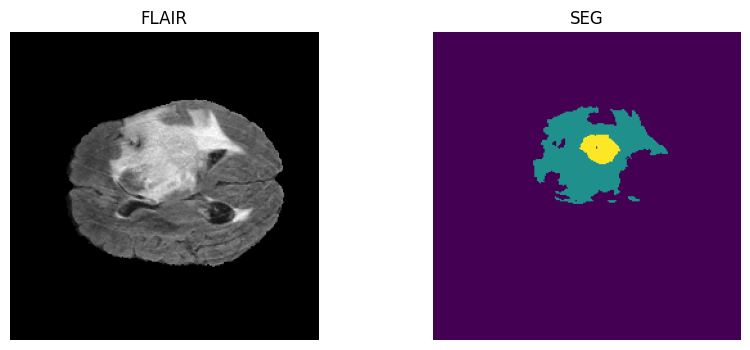

In [4]:
z = flair.shape[2]
mid = (z - 1) // 2   # guaranteed valid index (0..z-1)
print("z =", z, "mid =", mid)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(flair[:, :, mid], cmap='gray')
plt.title("FLAIR")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(seg[:, :, mid])
plt.title("SEG")
plt.axis("off")

plt.show()

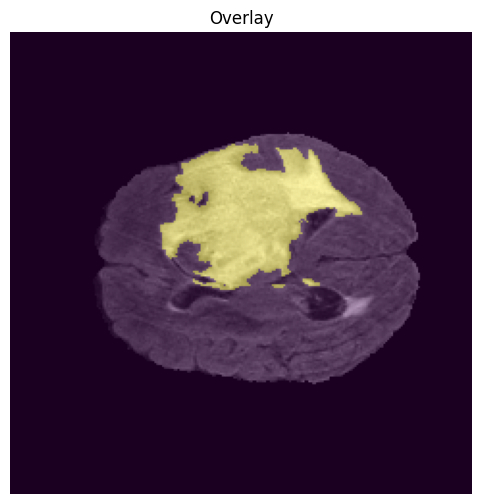

In [5]:
plt.figure(figsize=(6,6))
plt.imshow(flair[:,:,mid], cmap='gray')
plt.imshow(seg[:,:,mid] > 0, alpha=0.4)
plt.title("Overlay")
plt.axis("off")
plt.show()

In [6]:
#normalize and binarize
def normalize_zscore(volume):

    volume = volume.astype(np.float32)
    mean = np.mean(volume)
    std = np.std(volume)
    if std < 1e-6:
        std = 1.0
    return (volume - mean) / std

def binarize_mask(mask):
    return (mask > 0).astype(np.uint8)

In [7]:
#preparing 1 case 
flair_norm = normalize_zscore(flair)
seg_bin = binarize_mask(seg)

print("Normalized min/max:", flair_norm.min(), flair_norm.max())
print("Mask unique:", np.unique(seg_bin))

Normalized min/max: -0.38975167 8.971388
Mask unique: [0 1]


In [8]:
#Extract Only NonEmpty Slices
non_empty_indices = []

for i in range(flair_norm.shape[2]):
    if seg_bin[:, :, i].sum() > 0:
        non_empty_indices.append(i)

print("Total slices:", flair_norm.shape[2])
print("Tumor slices:", len(non_empty_indices))

Total slices: 155
Tumor slices: 83


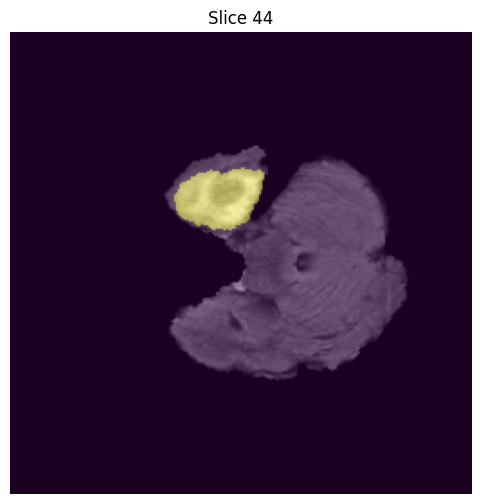

In [9]:
#visualize random tumor slice 256x256


rand_idx = random.choice(non_empty_indices)

img_slice = flair_norm[:, :, rand_idx]
mask_slice = seg_bin[:, :, rand_idx]

# Resize
img_resized = cv2.resize(img_slice, (256, 256))
mask_resized = cv2.resize(mask_slice, (256, 256), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(6,6))
plt.imshow(img_resized, cmap='gray')
plt.imshow(mask_resized, alpha=0.4)
plt.title(f"Slice {rand_idx}")
plt.axis("off")
plt.show()